Skylar wrote this; they're just screwing around with the data

# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import spacy
from tqdm import tqdm

# Get Movie Data

In [2]:
## Importing Gianluca's Movie Data Class
#sys.path.append('.')
from MovieData import MovieData

In [3]:
md = MovieData()

In [4]:
mdf = md.get_data()

In [5]:
mdf.head()

,id,original_title,budget,original_language,popularity,release_date,revenue,runtime,vote_average,vote_count,genres,keywords,production_companies,production_countries,spoken_languages,cast,crew
0,19995,Avatar,237000000,en,150.437577,2009-12-10,2787965087,162.0,7.2,11800,"[0, 1, 2, 3]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0, 1, 2, 3]","[0, 1]","[0, 1]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[0]
1,285,Pirates of the Caribbean: At World's End,300000000,en,139.082615,2007-05-19,961000000,169.0,6.9,4500,"[1, 2, 0]","[21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 3...","[4, 5, 6]",[0],[0],"[83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 9...",[1]
2,206647,Spectre,245000000,en,107.376788,2015-10-26,880674609,148.0,6.3,4466,"[0, 1, 4]","[37, 38, 39, 40, 41, 42, 43]","[7, 8, 9]","[1, 0]","[2, 0, 1, 3, 4]","[116, 117, 118, 119, 120, 121, 93, 122, 123, 1...",[2]
3,49026,The Dark Knight Rises,250000000,en,112.312950,2012-07-16,1084939099,165.0,7.6,9106,"[0, 4, 5, 6]","[44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 5...","[10, 11, 12, 13]",[0],[0],"[198, 199, 200, 201, 202, 203, 204, 205, 206, ...",[3]
4,49529,John Carter,260000000,en,43.926995,2012-03-07,284139100,132.0,6.1,2124,"[0, 1, 3]","[38, 65, 66, 5, 67, 9, 68, 69, 70, 71, 72, 73,...",[4],[0],[0],"[355, 356, 357, 358, 359, 360, 361, 362, 363, ...",[4]


# Screwing Around

In [7]:
mdf.columns

Index(['id', 'original_title', 'budget', 'original_language', 'popularity',
       'release_date', 'revenue', 'runtime', 'vote_average', 'vote_count',
       'genres', 'keywords', 'production_companies', 'production_countries',
       'spoken_languages', 'cast', 'crew'],
      dtype='str')

In [8]:
print(len(md.get_keywords()))
md.get_keywords()

9813


array(['culture clash', 'future', 'space war', ..., 'paper knife',
       'guitar case', 'postal worker'], shape=(9813,), dtype='<U48')

# The Plan

Ok, so here's what I'm planning on implementing:

0. Pick a target movie to compare to
1. Generate a list of "valid" movies to evaluate similarity
   - my first thought is eliminate some blacklisted languages
   - you could also blacklist genres I suppose
   - (you could maybe blacklist anything)
   - you could also have a cutoff for "bad" movies (based on populatity/reviews)
3. for each attribute (key) compute the distance between the target movie and all others
4. average the distances across attributes
   - this is some weighted average
   - one could have user inputs influence how important differnt attributes are to someone
6. sort the list of movies by distance to target and return the most similar

This is very k-nearest-neighbors inspired, but I don't think I would actually reuse code from that. Each attribute is going to need a different distance metric I think.

Some thoughts on having multiple target movies:
 - my first thought was to do the method for a single target movie multiple times, and then average the distance across the multiple target movies
 - one could also compute the distance between the target movies by attribute, and then increase the weights of those attributes in the overall distance comparison

## 1. Get Valid Movies

## 2. Attribute-Wise Distance

### Genre

It occured to me to do the thing I was planning to do with keywords with genre first as an initial test on a much smaller list.

We're still using SpaCy (https://spacy.io/). You'll need to run this to download the model used to parse text (you need this in addition to the spacy install).

`python -m spacy download en_core_web_md`

(if you ever want to un-download these models, use spacy-installer: https://github.com/rtmigo/spacy_installer_py)

In [6]:
nlp = spacy.load("en_core_web_md")
#nlp = spacy.load("en_core_web_lg")

In [12]:
genres = md.get_genres()
n_genres = len(genres)

I did check that all the genres are words in the medium words model.

In [14]:
words = set(nlp.vocab.strings)
oov_count = 0
for genre in genres:
    doc = nlp(str(genre))
    for word in doc:
        if word.is_oov: 
            print(word, 'is not in the language dictionary')
            oov_count += 1
if oov_count == 0: print('All genres are in the language dictionary')

All genres are in the language dictionary


In [17]:
genre_similarity = np.eye(n_genres)
for i in range(n_genres):
    # this matrix is lower triangular because in reality it's symmetric
    genre1 = nlp(str(genres[i]))
    for j in range(i):
        genre2 = nlp(str(genres[j]))
        genre_similarity[i,j] = genre2.similarity(genre1)
        genre_similarity[j, i] = genre_similarity[i,j]

In [18]:
np.savetxt('similarity_matrices/genre.csv', genre_similarity, delimiter=',')
np.savetxt('similarity_matrices/genre.npy', genre_similarity)

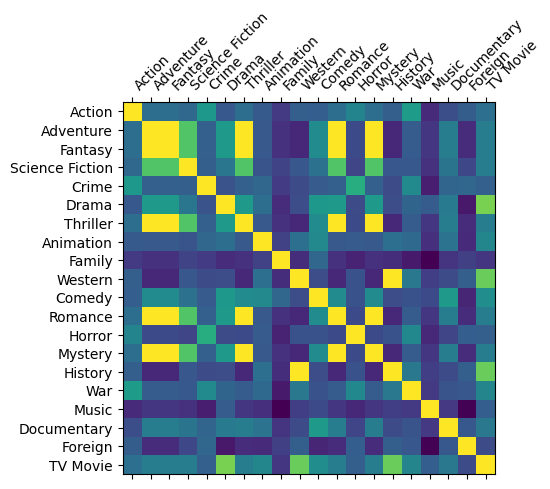

In [19]:
plt.matshow(genre_similarity)
ticks = np.arange(n_genres)
plt.xticks(ticks, genres, rotation=45, ha='left');
plt.yticks(ticks, genres, ha='right');
#plt.colorbar();

### Keywords

This is going to be one of the sticking points, as just doing a 1-hot style encoding isn't actually a very good way to do this. I would love to use a natural language processing module for this to actually compare meaning, and I might get to. 

SpaCy (https://spacy.io/) has tools to compare word similarity, and I think I'm going to give this a shot to come up with a global similarity matrix that we can then use to weight keyword similarity. Or something

In [8]:
keywords = md.get_keywords()

In [22]:
oov_words = []
for keyword in tqdm(keywords):
    doc = nlp(str(keyword))
    for word in doc:
        if word.is_oov: 
            oov_words.append(word)

100%|██████████████████████████████████████| 9813/9813 [00:20<00:00, 475.53it/s]


In [23]:
print('There are', len(oov_words), 'out-of vocabulary words in the keywords')
percent_oov = 100*(len(oov_words) / len(keywords) )
print(f'That is {percent_oov:1.2f}% of the keywords.')

There are 182 out-of vocabulary words in the keywords
That is 1.85% of the keywords.


this is actually an overestimate of out-of-vocab (oov) words because this is oov tokens, not oov keywords. There are more total tokens than there are total keywords. I could do it differently to count percetage of keywords with oov tokens, but that doesn't seem worth it. I manually look through them below, and they are kinda fucked up words.

In [24]:
oov_words

[aftercreditsstinger,
 duringcreditsstinger,
 myoko,
  ,
  ,
 baustelle,
 q*bert,
 apprendista,
  ,
 guantánamo,
 symbologist,
 galier,
 fabergé,
 eastindian,
  ,
  ,
 carolinam,
 glaciale,
  ,
 metereologist,
  ,
 lovesickness,
 vororte,
  ,
 overleven,
 bulldogg,
 lasergun,
 kubakrise,
 m.i.t,
 quatermain,
 ailul,
 raumschiffabsturz,
 nixe,
 laserpointer,
  ,
 thalassophobia,
 cattivissimo,
 wettermann,
 s.a.t,
 polynésie,
 reprioritizing,
 turboman,
 downworlder,
 shadowhunter,
 perónism,
  ,
   ,
 lasersight,
 cojote,
 mercifulness,
 orléans,
 preisgeld,
 teuflisch,
 rumpelstilzchen,
 autoritian,
 beforecreditsstinger,
 toxication,
 unsociability,
 urteil,
 chefin,
 valak,
 oberflächlichkeit,
 Γη,
 yucatec,
 schönbrunn,
  ,
 sexappeal,
 beförderung,
 discontentedness,
 displeasedness,
 strugatsky,
 testting,
  ,
 sexchat,
 tarkovskyesque,
 绝地奶霸,
 卧底肥妈,
 big爆任务,
 超级妈妈,
  ,
 ordensbruder,
 bronko,
 nagurski,
 coaction,
 pleite,
 s.w.a.t,
 immoderateness,
 englishwoman,
 hemophagia,
 

In [10]:
n_keywords = len(keywords)
keyword_similarity = np.eye(n_keywords)
for i in tqdm(range(n_keywords)):
    # this matrix is lower triangular because in reality it's symmetric
    keyword1 = nlp(str(keywords[i]))
    for j in range(i):
        keyword2 = nlp(str(keywords[j]))
        keyword_similarity[i,j] = keyword2.similarity(keyword1)
        keyword_similarity[j,i] = keyword_similarity[i,j]
        
    ## Save points.. this is going to take a while
    if i % 20 ==0: #saving itself turned out to take a really long time so we're spacing that out more
        np.savetxt('similarity_matrices/keywords_progress.csv', keyword_similarity, delimiter=',')
        np.savetxt('similarity_matrices/keywords_progress.npy', keyword_similarity)

## Final Save
np.savetxt('similarity_matrices/keywords.csv', keyword_similarity, delimiter=',')
np.savetxt('similarity_matrices/keywords.npy', keyword_similarity)

  0%|▏                                                 | 34/9813 [01:00<2:21:59,  1.15it/s]/var/folders/p5/6ybz6qb10gb95zt5kpt627p80000gq/T/ipykernel_49447/387652245.py:8: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  keyword_similarity[i,j] = keyword2.similarity(keyword1)
100%|███████████████████████████████████████████████| 9813/9813 [32:55:58<00:00, 12.08s/it]


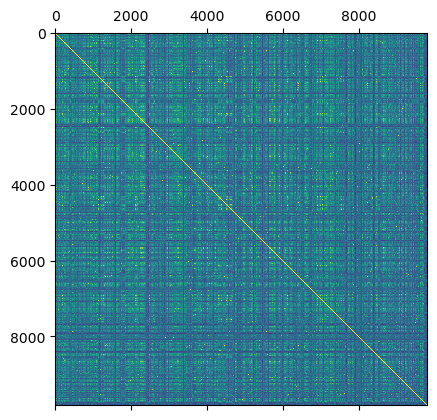

In [11]:
plt.matshow(keyword_similarity)